# S2 Coursework DRAFT

## Question 1: Accident data

Load the intervals 𝐼𝑖 from the coal_mining_accident_data.dat file. Plot the cumulative number of accidents over time. What is the mean rate of accidents over the total period covered by the data?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
mining_data = np.loadtxt(os.path.join('data','coal_mining_accident_data.dat'))
flattened_data = np.ndarray.flatten(mining_data, order="C")
flattened_data_cumulative = np.copy(flattened_data)
print(flattened_data)
print(np.shape(flattened_data))

total_period = 40550
total_events = 191

for i in range(len(flattened_data)-1):
    flattened_data_cumulative[i+1:] += flattened_data[i]
print(flattened_data_cumulative)
number_of_accidents = np.arange(0, len(flattened_data_cumulative), 1)

[1.570e+02 6.500e+01 5.300e+01 9.300e+01 1.270e+02 1.760e+02 2.200e+01
 1.205e+03 1.643e+03 3.120e+02 1.230e+02 1.860e+02 1.700e+01 2.400e+01
 2.180e+02 5.500e+01 6.100e+01 6.440e+02 5.400e+01 5.360e+02 2.000e+00
 2.300e+01 5.380e+02 9.100e+01 2.000e+00 9.300e+01 7.800e+01 4.670e+02
 3.260e+02 1.450e+02 1.240e+02 9.200e+01 1.870e+02 1.430e+02 0.000e+00
 5.900e+01 9.900e+01 8.710e+02 1.312e+03 7.500e+01 1.200e+01 1.970e+02
 3.400e+01 1.600e+01 3.780e+02 3.150e+02 3.260e+02 4.800e+01 3.480e+02
 3.640e+02 4.000e+00 4.310e+02 1.010e+02 2.700e+01 3.600e+01 5.900e+01
 2.750e+02 1.230e+02 7.450e+02 3.700e+01 1.000e+01 1.600e+01 4.100e+01
 1.440e+02 1.500e+01 6.100e+01 5.400e+01 4.560e+02 2.170e+02 1.900e+01
 2.160e+02 1.540e+02 1.390e+02 4.500e+01 3.100e+01 1.000e+00 2.170e+02
 4.980e+02 1.200e+02 1.560e+02 8.000e+01 9.500e+01 4.200e+01 6.000e+00
 2.150e+02 1.300e+01 1.130e+02 4.900e+01 2.750e+02 4.700e+01 1.200e+01
 2.500e+01 1.000e+00 2.080e+02 1.100e+01 1.890e+02 3.200e+01 1.310e+02
 2.000

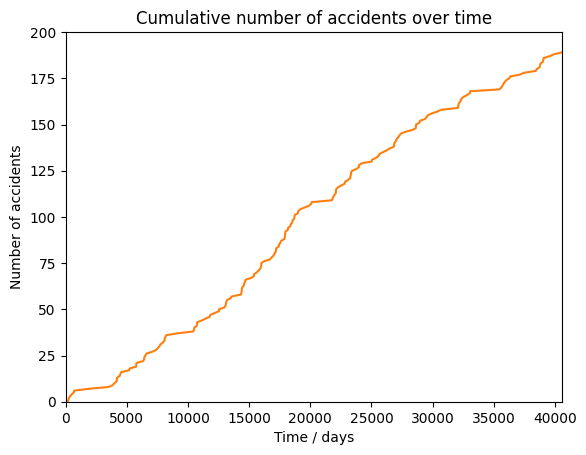

In [4]:
plt.plot(flattened_data_cumulative, number_of_accidents, color="tab:orange")
plt.xlabel("Time / days")
plt.ylabel("Number of accidents")
plt.title("Cumulative number of accidents over time")
plt.xlim(0,40550)
plt.ylim(0,200)
plt.show()

In [16]:
mean_rate = total_events / (total_period)
print(f"Mean rate of accidents: {mean_rate:.4f} per day")
mean_rate_year = number_of_accidents[-1] / (total_period / 365) # Convert total period from years to days
print(f"Mean rate of accidents: {mean_rate_year:.2f} per year")

Mean rate of accidents: 0.0047 per day
Mean rate of accidents: 1.70 per year


## Question 2: Priors

Model 𝑀𝑘 has 2𝑘+1 parameters: the 𝑘 change point positions 𝑠𝑗 and the 𝑘+1 heights ℎ𝑗. A priori, the heights are taken to be identically and independently distributed as ℎ𝑗 ∼ 𝛤(𝛼, 𝛽) with 𝛼 = 1 and 𝛽 = 200 days and the positions 𝑠1, 𝑠2, . . . , 𝑠𝑘 are taken to be distributed as the even-numbered order statistics from 2𝑘 + 1 points independently uniformly distributed on the interval [0, 𝐿].

### Part A

An alternative prior for the change point positions would be to just take the 𝑘 plain order statistics. This would involve drawing 𝑘 independent uniform random variables on [0, 𝐿] and sorting into ascending order. Describe qualitatively (in under 200 words) the difference between this prior and the even-numbered order statistics prior. Illustrate your answer using a suitable plot of the two priors for 𝑘 = 4.

(4,)
[ 6986.54089732 22324.63647056 29815.65055264 38521.79271162]
(4,)
[14576.92564234 17179.53649646 22904.18808939 34075.19593193]


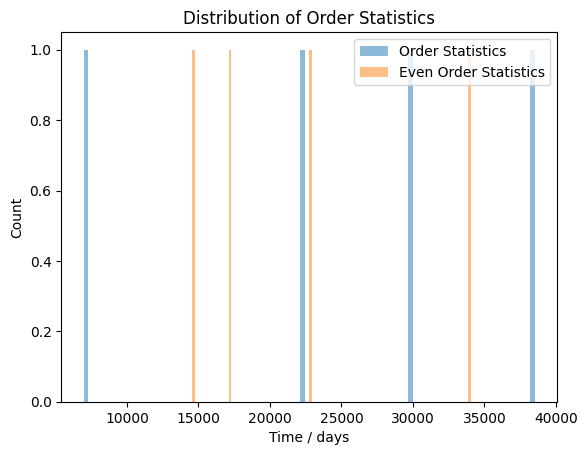

In [6]:
from scipy import special

def gamma(x, alpha, beta):
    pdf = (beta ** alpha) * np.exp(-beta * x) / special.gamma(alpha)
    return pdf

k = 4
order_statistics = np.sort(np.random.uniform(0, total_period, k))
print(np.shape(order_statistics))
print(order_statistics)
even_order_statistics = np.sort(np.random.uniform(0, total_period, 2 * k + 1))[1:-1:2]
print(np.shape(even_order_statistics))
print(even_order_statistics)

plt.hist(order_statistics, bins=100, density=False, alpha=0.5, label='Order Statistics')
plt.hist(even_order_statistics, bins=100, density=False, alpha=0.5, label='Even Order Statistics')
plt.xlabel("Time / days")
plt.ylabel("Count")
plt.title("Distribution of Order Statistics")
plt.legend()
plt.show()

## Question 3: The constant rate model

The prior on $h_0$ is 

\begin{equation}
    \pi(h_0|M_0)=\beta^\alpha\exp(-\beta h)/\Gamma(\alpha),
\end{equation}

where $\alpha=1$, $\beta=200\;\text{days}$. In the constant rate case, the log-likelihood is simply

\begin{equation}
    \log\mathcal{L}(\{I_i\}|h_0,M_0)=N\log h_0-h_0L.
\end{equation}

The posterior on $h_0$ is thus

\begin{equation}
    P(h_0|\{I_i\}, M_0)=200h_0^N\exp(-h_0(200+L)).
\end{equation}

-1210.0228072596817
-inf
5.298317366548036
-2.7016826334519637


/tmp/ipykernel_2709/1066448985.py:14: RuntimeWarning: divide by zero encountered in log
  return total_events * np.log(h) - h * total_period


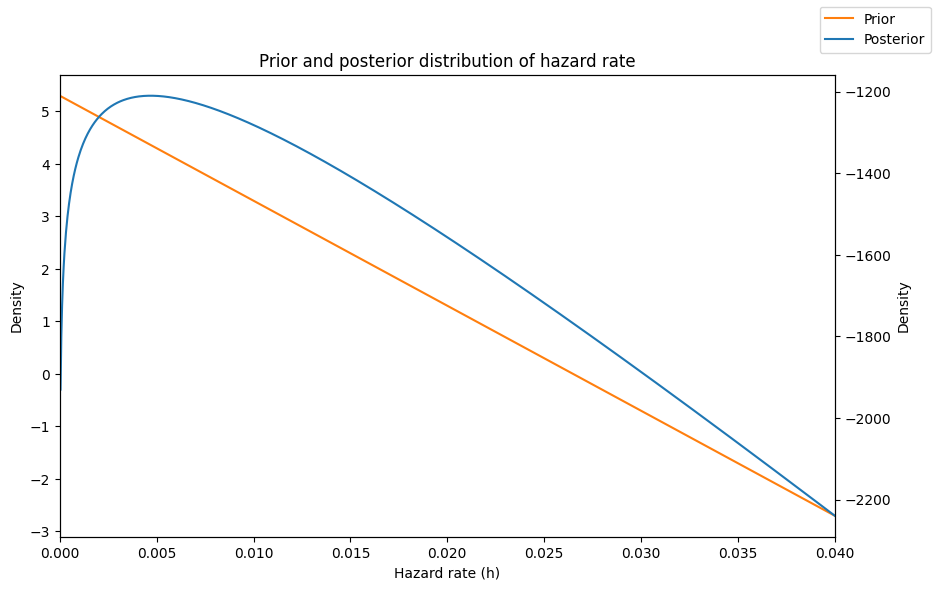

In [37]:
alpha = 1
beta = 200

def constant_rate_prior(h):
    return beta ** alpha * np.exp(-beta * h) / special.gamma(alpha)

def log_constant_rate_prior(h):
    return alpha * np.log(beta) - beta * h - special.gammaln(alpha)

def constant_rate_likelihood(h):
    return h ** total_events * np.exp(-h * total_period)

def log_constant_rate_likelihood(h):
    return total_events * np.log(h) - h * total_period

def constant_rate_posterior(h):
    return constant_rate_prior(h) * constant_rate_likelihood(h)

def log_constant_rate_posterior(h):
    return log_constant_rate_prior(h) + log_constant_rate_likelihood(h)

h_values = np.linspace(0, 0.04, 1000)
log_posterior_values = log_constant_rate_posterior(h_values)
print(np.max(log_posterior_values))
print(np.min(log_posterior_values))
log_prior_values = log_constant_rate_prior(h_values)
print(np.max(log_prior_values))
print(np.min(log_prior_values))
fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()
#plt.plot(h_values, log_posterior_values, color="tab:blue", label="Posterior")
ax.plot(h_values, log_prior_values, color="tab:orange", label="Prior")
ax.set_xlabel("Hazard rate (h)")
ax.set_ylabel("Density")
ax.set_title("Prior and posterior distribution of hazard rate")
ax.set_xlim(0, 0.04)
ax2.plot(h_values, log_posterior_values, color="tab:blue", label="Posterior")
ax2.set_ylabel("Density")
fig.legend(loc="upper right")
plt.show()